### Multi-Agent Systems & Workflow Patterns

#### 一、为什么需要多智能体  
多智能体的核心逻辑为分而治之：
1. 突破模型能力的上限：实验表明，将复杂任务拆解给多个角色（如“编写者”和“审核者”），其表现通常比让一个模型独立完成要好得多。例如，在安全审查任务中，多智能体架构比单智能体架构的召回率高出约 20%
2. 模块化与可维护性：就像编写软件代码一样，模块化设计更易于调试。你可以通过修改某个特定 Agent 的 Prompt 或更换模型，而无需重写整个系统。
3. 异构工具集成：不同的 Agent 可以专注于不同的工具（例如一个搜网页，一个写代码），这样能有效减少上下文冲突。
4. 引入纠错机制：通过“辩论”或“审核”环节，智能体可以互相发现并纠正幻觉（Hallucination）或逻辑错误

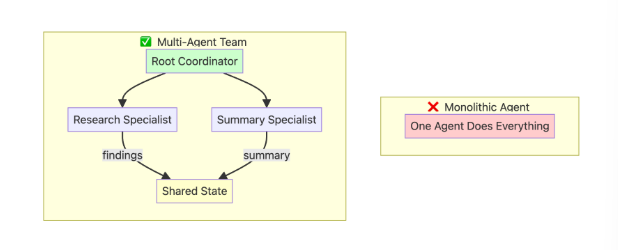

#### 二、核心工作流模式
1. 顺行/串行工作流  
  - 逻辑：上一个节点的输入是下一个节点的输出
  - 示例场景：文章撰写  

  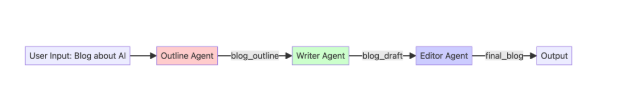

2. 并行工作流
同时启动多个Agent执行任务，最后汇总结果
- 逻辑：任务之间没有依赖关系，追求效率和覆盖度
- 示例场景：复杂信息检索  
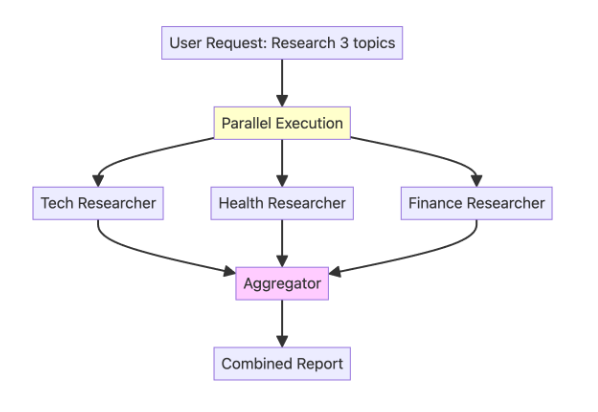

3. 循环/迭代工作流  

包含反馈环路，允许 Agent 反复修改直到达到目标
- 逻辑：最典型的就是 ReAct (Reasoning + Acting) 循环。Agent 观察环境 -> 思考下一步 -> 采取行动 -> 再次观察。
- 示例场景：代码 Debug。Agent 编写代码 -> 运行测试 -> 若失败则根据报错信息重新修改代码（直到通过测试）  
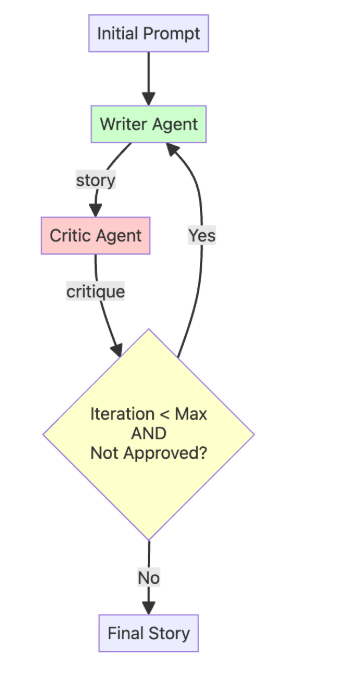

#### 三、如何选择合适的模式

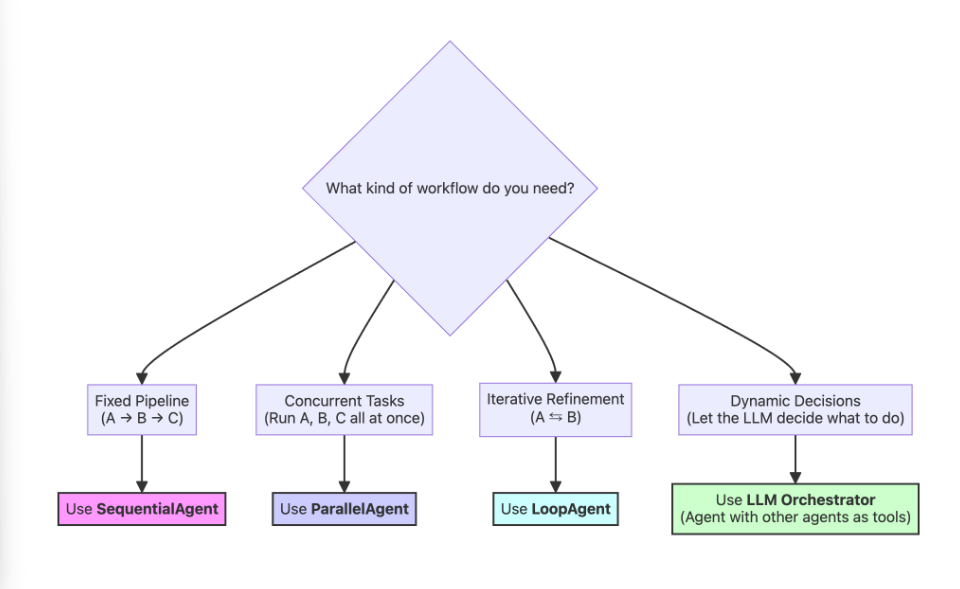

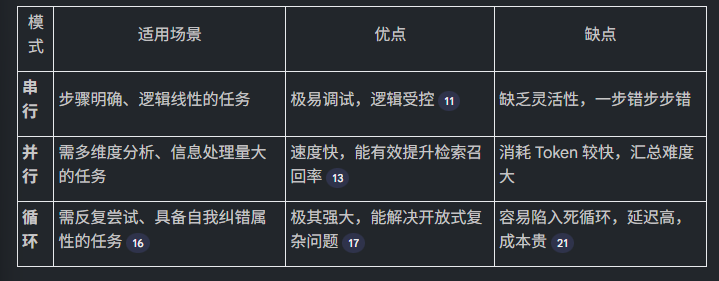

In [1]:
import os

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

if not GOOGLE_API_KEY:
    raise ValueError("GOOGLE_API_KEY not found in environment variables")

print("API Key loaded successfully.")

API Key loaded successfully.


In [2]:
from google.adk.agents import Agent, SequentialAgent, ParallelAgent, LoopAgent
from google.adk.models.google_llm import Gemini
from google.adk.runners import InMemoryRunner
from google.adk.tools import AgentTool, FunctionTool, google_search
from google.genai import types

print("✅ ADK components imported successfully.")

✅ ADK components imported successfully.


In [3]:
retry_config=types.HttpRetryOptions(
    attempts=5,  # Maximum retry attempts
    exp_base=7,  # Delay multiplier
    initial_delay=1,
    http_status_codes=[429, 500, 503, 504], # Retry on these HTTP errors
)

In [4]:
# Research Agent: Its job is to use the google_search tool and present findings.
research_agent = Agent(
    name="ResearchAgent",
    model=Gemini(
        model="gemini-2.5-flash-lite",
        retry_options=retry_config
    ),
    instruction="""You are a specialized research agent. Your only job is to use the
    google_search tool to find 2-3 pieces of relevant information on the given topic and present the findings with citations.""",
    tools=[google_search],
    output_key="research_findings",  # The result of this agent will be stored in the session state with this key.
)

print("✅ research_agent created.")

✅ research_agent created.


In [5]:
# Summarizer Agent: Its job is to summarize the text it receives.
summarizer_agent = Agent(
    name="SummarizerAgent",
    model=Gemini(
        model="gemini-2.5-flash-lite",
        retry_options=retry_config
    ),
    # The instruction is modified to request a bulleted list for a clear output format.
    instruction="""Read the provided research findings: {research_findings}
Create a concise summary as a bulleted list with 3-5 key points.""",
    output_key="final_summary",
)

print("✅ summarizer_agent created.")

✅ summarizer_agent created.


In [6]:
# Root Coordinator: Orchestrates the workflow by calling the sub-agents as tools.
root_agent = Agent(
    name="ResearchCoordinator",
    model=Gemini(
        model="gemini-2.5-flash-lite",
        retry_options=retry_config
    ),
    # This instruction tells the root agent HOW to use its tools (which are the other agents).
    instruction="""You are a research coordinator. Your goal is to answer the user's query by orchestrating a workflow.
1. First, you MUST call the `ResearchAgent` tool to find relevant information on the topic provided by the user.
2. Next, after receiving the research findings, you MUST call the `SummarizerAgent` tool to create a concise summary.
3. Finally, present the final summary clearly to the user as your response.""",
    # We wrap the sub-agents in `AgentTool` to make them callable tools for the root agent.
    tools=[AgentTool(research_agent), AgentTool(summarizer_agent)],
)

print("✅ root_agent created.")

✅ root_agent created.


In [7]:
runner = InMemoryRunner(agent=root_agent)
response = await runner.run_debug(
    "What are the latest advancements in quantum computing and what do they mean for AI?"
)


 ### Created new session: debug_session_id

User > What are the latest advancements in quantum computing and what do they mean for AI?


ResearchCoordinator > Quantum computing advancements are set to revolutionize AI by providing unprecedented computational power and novel algorithmic approaches, leading to what's often termed \"Quantum AI.\"

Here's a summary of the key advancements and their implications for AI:

*   **Enhanced Computational Power & Speed:** Quantum computers can process information exponentially faster than classical computers, drastically speeding up AI tasks like training deep learning models.
*   **Advanced Algorithm Development:** New quantum algorithms are emerging that can handle more complex problems, leading to more accurate AI decision-making and pattern recognition.
*   **Improved Optimization:** Quantum computing's ability to explore numerous possibilities simultaneously makes it ideal for optimizing AI models and resource allocation.
*   **Solving Intractable Problems:** Quantum computers can tackle complex problems currently beyond classical reach, promising breakthroughs in areas like 

In [8]:
### Sequential Workflows
# Outline Agent: Creates the initial blog post outline.
outline_agent = Agent(
    name="OutlineAgent",
    model=Gemini(
        model="gemini-2.5-flash-lite",
        retry_options=retry_config
    ),
    instruction="""Create a blog outline for the given topic with:
    1. A catchy headline
    2. An introduction hook
    3. 3-5 main sections with 2-3 bullet points for each
    4. A concluding thought""",
    output_key="blog_outline",  # The result of this agent will be stored in the session state with this key.
)

print("✅ outline_agent created.")

✅ outline_agent created.


In [9]:
# Writer Agent: Writes the full blog post based on the outline from the previous agent.
writer_agent = Agent(
    name="WriterAgent",
    model=Gemini(
        model="gemini-2.5-flash-lite",
        retry_options=retry_config
    ),
    # The `{blog_outline}` placeholder automatically injects the state value from the previous agent's output.
    instruction="""Following this outline strictly: {blog_outline}
    Write a brief, 200 to 300-word blog post with an engaging and informative tone.""",
    output_key="blog_draft",  # The result of this agent will be stored with this key.
)

print("✅ writer_agent created.")

✅ writer_agent created.


In [10]:
# Editor Agent: Edits and polishes the draft from the writer agent.
editor_agent = Agent(
    name="EditorAgent",
    model=Gemini(
        model="gemini-2.5-flash-lite",
        retry_options=retry_config
    ),
    # This agent receives the `{blog_draft}` from the writer agent's output.
    instruction="""Edit this draft: {blog_draft}
    Your task is to polish the text by fixing any grammatical errors, improving the flow and sentence structure, and enhancing overall clarity.""",
    output_key="final_blog",  # This is the final output of the entire pipeline.
)

print("✅ editor_agent created.")

✅ editor_agent created.


In [11]:
root_agent = SequentialAgent(
    name="BlogPipeline",
    sub_agents=[outline_agent, writer_agent, editor_agent],
)

print("✅ Sequential Agent created.")

✅ Sequential Agent created.


In [12]:
runner = InMemoryRunner(agent=root_agent)
response = await runner.run_debug(
    "Write a blog post about the benefits of multi-agent systems for software developers"
)


 ### Created new session: debug_session_id

User > Write a blog post about the benefits of multi-agent systems for software developers
OutlineAgent > ## Unlock Your Development Superpowers: The Magic of Multi-Agent Systems

Ever feel like you're juggling too many tasks, or that your software is struggling to handle complex, dynamic environments? Imagine a world where intelligent, independent agents collaborate to solve problems, automate processes, and create more robust and adaptable software. Welcome to the exciting realm of Multi-Agent Systems (MAS), and as a software developer, understanding them is about to become your new superpower.

### 1. Smarter Problem Solving: Divide and Conquer, Agent Style

*   **Decomposition of Complexity:** MAS allow you to break down intricate problems into smaller, manageable sub-problems. Each agent can be specialized to handle a specific part of the solution, leading to more elegant and efficient designs.
*   **Parallel Processing & Speed:** By di

In [13]:
### Parallel Workflows
# Tech Researcher: Focuses on AI and ML trends.
tech_researcher = Agent(
    name="TechResearcher",
    model=Gemini(
        model="gemini-2.5-flash-lite",
        retry_options=retry_config
    ),
    instruction="""Research the latest AI/ML trends. Include 3 key developments,
the main companies involved, and the potential impact. Keep the report very concise (100 words).""",
    tools=[google_search],
    output_key="tech_research",  # The result of this agent will be stored in the session state with this key.
)

print("✅ tech_researcher created.")

✅ tech_researcher created.


In [14]:
# Health Researcher: Focuses on medical breakthroughs.
health_researcher = Agent(
    name="HealthResearcher",
    model=Gemini(
        model="gemini-2.5-flash-lite",
        retry_options=retry_config
    ),
    instruction="""Research recent medical breakthroughs. Include 3 significant advances,
their practical applications, and estimated timelines. Keep the report concise (100 words).""",
    tools=[google_search],
    output_key="health_research",  # The result will be stored with this key.
)

print("✅ health_researcher created.")

✅ health_researcher created.


In [15]:
# Finance Researcher: Focuses on fintech trends.
finance_researcher = Agent(
    name="FinanceResearcher",
    model=Gemini(
        model="gemini-2.5-flash-lite",
        retry_options=retry_config
    ),
    instruction="""Research current fintech trends. Include 3 key trends,
their market implications, and the future outlook. Keep the report concise (100 words).""",
    tools=[google_search],
    output_key="finance_research",  # The result will be stored with this key.
)

print("✅ finance_researcher created.")

✅ finance_researcher created.


In [16]:
# The AggregatorAgent runs *after* the parallel step to synthesize the results.
aggregator_agent = Agent(
    name="AggregatorAgent",
    model=Gemini(
        model="gemini-2.5-flash-lite",
        retry_options=retry_config
    ),
    # It uses placeholders to inject the outputs from the parallel agents, which are now in the session state.
    instruction="""Combine these three research findings into a single executive summary:

    **Technology Trends:**
    {tech_research}
    
    **Health Breakthroughs:**
    {health_research}
    
    **Finance Innovations:**
    {finance_research}
    
    Your summary should highlight common themes, surprising connections, and the most important key takeaways from all three reports. The final summary should be around 200 words.""",
    output_key="executive_summary",  # This will be the final output of the entire system.
)

print("✅ aggregator_agent created.")

✅ aggregator_agent created.


In [17]:
# The ParallelAgent runs all its sub-agents simultaneously.
parallel_research_team = ParallelAgent(
    name="ParallelResearchTeam",
    sub_agents=[tech_researcher, health_researcher, finance_researcher],
)

# This SequentialAgent defines the high-level workflow: run the parallel team first, then run the aggregator.
root_agent = SequentialAgent(
    name="ResearchSystem",
    sub_agents=[parallel_research_team, aggregator_agent],
)

print("✅ Parallel and Sequential Agents created.")

✅ Parallel and Sequential Agents created.


In [18]:
runner = InMemoryRunner(agent=root_agent)
response = await runner.run_debug(
    "Run the daily executive briefing on Tech, Health, and Finance"
)


 ### Created new session: debug_session_id

User > Run the daily executive briefing on Tech, Health, and Finance
FinanceResearcher > As requested, here is a daily executive briefing covering Tech, Health, and Finance:

**Tech Executive Briefing:**
The tech landscape is at a strategic inflection point, with companies navigating payment volatility and regulatory fragmentation. AI in tech is a key focus, emphasizing the need for trust and risk management amidst evolving legal frameworks. Emerging technologies like AI, machine learning, blockchain, and IoT are gaining traction for their practical business applications, driving innovation in enterprise modernization and customer experience.

**Health Executive Briefing:**
The healthcare sector is grappling with the integration of AI, requiring ethics-centered approaches and practical governance playbooks to build trust with clinicians and patients. Workforce resilience and evolving payment models are also critical concerns. Data breaches s

In [19]:
### LOOP Workflows
# This agent runs ONCE at the beginning to create the first draft.
initial_writer_agent = Agent(
    name="InitialWriterAgent",
    model=Gemini(
        model="gemini-2.5-flash-lite",
        retry_options=retry_config
    ),
    instruction="""Based on the user's prompt, write the first draft of a short story (around 100-150 words).
    Output only the story text, with no introduction or explanation.""",
    output_key="current_story",  # Stores the first draft in the state.
)

print("✅ initial_writer_agent created.")

✅ initial_writer_agent created.


In [20]:
# This agent's only job is to provide feedback or the approval signal. It has no tools.
critic_agent = Agent(
    name="CriticAgent",
    model=Gemini(
        model="gemini-2.5-flash-lite",
        retry_options=retry_config
    ),
    instruction="""You are a constructive story critic. Review the story provided below.
    Story: {current_story}
    
    Evaluate the story's plot, characters, and pacing.
    - If the story is well-written and complete, you MUST respond with the exact phrase: "APPROVED"
    - Otherwise, provide 2-3 specific, actionable suggestions for improvement.""",
    output_key="critique",  # Stores the feedback in the state.
)

print("✅ critic_agent created.")

✅ critic_agent created.


In [21]:
# This is the function that the RefinerAgent will call to exit the loop.
def exit_loop():
    """Call this function ONLY when the critique is 'APPROVED', indicating the story is finished and no more changes are needed."""
    return {"status": "approved", "message": "Story approved. Exiting refinement loop."}


print("✅ exit_loop function created.")

✅ exit_loop function created.


In [22]:
# This agent refines the story based on critique OR calls the exit_loop function.
refiner_agent = Agent(
    name="RefinerAgent",
    model=Gemini(
        model="gemini-2.5-flash-lite",
        retry_options=retry_config
    ),
    instruction="""You are a story refiner. You have a story draft and critique.
    
    Story Draft: {current_story}
    Critique: {critique}
    
    Your task is to analyze the critique.
    - IF the critique is EXACTLY "APPROVED", you MUST call the `exit_loop` function and nothing else.
    - OTHERWISE, rewrite the story draft to fully incorporate the feedback from the critique.""",
    output_key="current_story",  # It overwrites the story with the new, refined version.
    tools=[
        FunctionTool(exit_loop)
    ],  # The tool is now correctly initialized with the function reference.
)

print("✅ refiner_agent created.")

✅ refiner_agent created.


In [23]:
# The LoopAgent contains the agents that will run repeatedly: Critic -> Refiner.
story_refinement_loop = LoopAgent(
    name="StoryRefinementLoop",
    sub_agents=[critic_agent, refiner_agent],
    max_iterations=2,  # Prevents infinite loops
)

# The root agent is a SequentialAgent that defines the overall workflow: Initial Write -> Refinement Loop.
root_agent = SequentialAgent(
    name="StoryPipeline",
    sub_agents=[initial_writer_agent, story_refinement_loop],
)

print("✅ Loop and Sequential Agents created.")

✅ Loop and Sequential Agents created.


In [24]:
runner = InMemoryRunner(agent=root_agent)
response = await runner.run_debug(
    "Write a short story about a lighthouse keeper who discovers a mysterious, glowing map"
)


 ### Created new session: debug_session_id

User > Write a short story about a lighthouse keeper who discovers a mysterious, glowing map
InitialWriterAgent > The salty air whipped Elias’s beard as he climbed the spiral stairs. For thirty years, the beam of the lighthouse had been his only companion, a steady pulse against the encroaching darkness. Tonight, however, something was different. Tucked beneath a loose floorboard in the lantern room, he found it – a rolled parchment, brittle with age. Unfurling it, Elias gasped. It wasn't paper, but some phosphorescent hide that pulsed with an inner light. Intricate lines, like celestial constellations, crisscrossed its surface, forming a map he didn't recognize. A single, shimmering 'X' marked a spot far out at sea, a place known only for treacherous currents and lost ships. The lighthouse beam swept across the water, but the map glowed brighter, an insistent, silent beckoning.
CriticAgent > This is a promising start to a story, creating a 